In [40]:
!pip install matplotlib

In [41]:
import random
import time
import itertools
import os
import re

Read txt files

In [42]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z ]', '', text)  
    return text

def load_documents():
    documents = {}
    for i in range(1, 5):
        filename = f"minhash/D{i}.txt"
        if not os.path.exists(filename):
            print(f"File {filename} not found!")
            exit()

        with open(filename, 'r', encoding='utf-8') as f:
            content = f.read().strip()
            documents[f"D{i}"] = clean_text(content)

    return documents


documents = load_documents()

### 1. Create k-Grams

In [43]:
## Character k-grams

def char_kgrams(text, k):
    grams = set()
    for i in range(len(text) - k + 1):
        gram = text[i:i+k]
        grams.add(gram)
    return grams

## Word k-grams

def word_kgrams(text, k):
    words = text.split()
    grams = set()
    for i in range(len(words) - k + 1):
        grams.add(tuple(words[i:i+k]))
    return grams

Construct All K-Grams

In [44]:
char2 = {}
char3 = {}
word2 = {}

for name, text in documents.items():
    char2[name] = char_kgrams(text, 2)
    char3[name] = char_kgrams(text, 3)
    word2[name] = word_kgrams(text, 2)

Exact Jaccard Function

In [45]:
def jaccard(setA, setB):
    intersection = len(setA.intersection(setB))
    union = len(setA.union(setB))
    return intersection / union if union != 0 else 0

MinHash Implementation

In [46]:
## Convert k-gram to Integer

def gram_to_int(gram):
    return abs(hash(gram))

## Generate Hash Functions

def generate_hash_functions(t, m):
    hash_functions = []
    for _ in range(t):
        a = random.randint(1, m-1)
        b = random.randint(0, m-1)
        hash_functions.append((a, b))
    return hash_functions

## Compute MinHash Signature

def compute_minhash_signature(grams, hash_functions, m):
    signature = []
    gram_ids = [gram_to_int(g) for g in grams]

    for (a, b) in hash_functions:
        min_hash = float('inf')
        for gid in gram_ids:
            h = (a * gid + b) % m
            if h < min_hash:
                min_hash = h
        signature.append(min_hash)

    return signature

## Approximate Jaccard

def minhash_similarity(sig1, sig2):
    matches = sum(1 for i in range(len(sig1)) if sig1[i] == sig2[i])
    return matches / len(sig1)


#### A: For each value of ( t ), report the approximate Jaccard similarity between the pair of documents D1 and D2, estimating the Jaccard similarity:

In [47]:
m = 20011
t_values = [20, 60, 150, 300, 600]

exact_sim = jaccard(char3["D1"], char3["D2"])
print("Exact 3-gram Jaccard(D1, D2) =", round(exact_sim, 4), "\n")

for t in t_values:
    start = time.time()

    hash_functions = generate_hash_functions(t, m)

    sig1 = compute_minhash_signature(char3["D1"], hash_functions, m)
    sig2 = compute_minhash_signature(char3["D2"], hash_functions, m)

    approx_sim = minhash_similarity(sig1, sig2)

    end = time.time()

    print(f"t = {t}")
    print(f"Approx Jaccard = {approx_sim:.4f}")
    print(f"Time taken = {end - start:.4f} seconds\n")

Exact 3-gram Jaccard(D1, D2) = 0.978 

t = 20
Approx Jaccard = 1.0000
Time taken = 0.0022 seconds

t = 60
Approx Jaccard = 0.9833
Time taken = 0.0056 seconds

t = 150
Approx Jaccard = 0.9600
Time taken = 0.0132 seconds

t = 300
Approx Jaccard = 0.9567
Time taken = 0.0270 seconds

t = 600
Approx Jaccard = 0.9867
Time taken = 0.0552 seconds



#### B: Compute the Jaccard similarity between all pairs of documents for each type of k-gram.

In [48]:
doc_pairs = list(itertools.combinations(documents.keys(), 2))

for name, gram_dict in [
    ("Character 2-gram", char2),
    ("Character 3-gram", char3),
    ("Word 2-gram", word2)
]:
    print(f"\n{name}")
    for d1, d2 in doc_pairs:
        sim = jaccard(gram_dict[d1], gram_dict[d2])
        print(f"{d1} - {d2} : {sim:.4f}")


Character 2-gram
D1 - D2 : 0.9811
D1 - D3 : 0.8157
D1 - D4 : 0.6444
D2 - D3 : 0.8000
D2 - D4 : 0.6413
D3 - D4 : 0.6530

Character 3-gram
D1 - D2 : 0.9780
D1 - D3 : 0.5804
D1 - D4 : 0.3051
D2 - D3 : 0.5680
D2 - D4 : 0.3059
D3 - D4 : 0.3121

Word 2-gram
D1 - D2 : 0.9408
D1 - D3 : 0.1823
D1 - D4 : 0.0302
D2 - D3 : 0.1737
D2 - D4 : 0.0303
D3 - D4 : 0.0161


### 2. Min-Hashing

##### A: For each value of ( t ), report the approximate Jaccard similarity between the pair of documents D1 and D2, estimating the Jaccard similarity. ( m greater than 10,000 ).

In [49]:
t_values = [20, 60, 150, 300, 600, 800, 1000, 1500]
m = 30031

for t in t_values:
    start = time.time()

    hash_functions = generate_hash_functions(t,m)

    sig1 = compute_minhash_signature(char3["D1"], hash_functions, m)
    sig2 = compute_minhash_signature(char3["D2"], hash_functions, m)

    approx_sim = minhash_similarity(sig1, sig2)

    end = time.time()

    print(f"t = {t}")
    print(f"Approximate Jaccard = {approx_sim:.6f}")
    print(f"Time taken = {end - start:.6f} seconds\n")

t = 20
Approximate Jaccard = 0.950000
Time taken = 0.001906 seconds

t = 60
Approximate Jaccard = 0.983333
Time taken = 0.005310 seconds

t = 150
Approximate Jaccard = 0.973333
Time taken = 0.013418 seconds

t = 300
Approximate Jaccard = 0.976667
Time taken = 0.026467 seconds

t = 600
Approximate Jaccard = 0.978333
Time taken = 0.055124 seconds

t = 800
Approximate Jaccard = 0.980000
Time taken = 0.072015 seconds

t = 1000
Approximate Jaccard = 0.979000
Time taken = 0.090734 seconds

t = 1500
Approximate Jaccard = 0.982000
Time taken = 0.137340 seconds



##### B: What seems to be a good value for ( t )? You may run more experiments. 

Exact Jaccard (D1, D2) = 0.9780

     t    Approx J     Error    Time (s)  Assessment
--------------------------------------------------------------
    20      1.0000    0.0220      0.0019s  Good
    60      0.9500    0.0280      0.0055s  Good
   150      0.9667    0.0113      0.0132s  Good
   300      0.9733    0.0046      0.0261s  Excellent
   600      0.9800    0.0020      0.0548s  Excellent
--------------------------------------------------------------
 Exact      0.9780


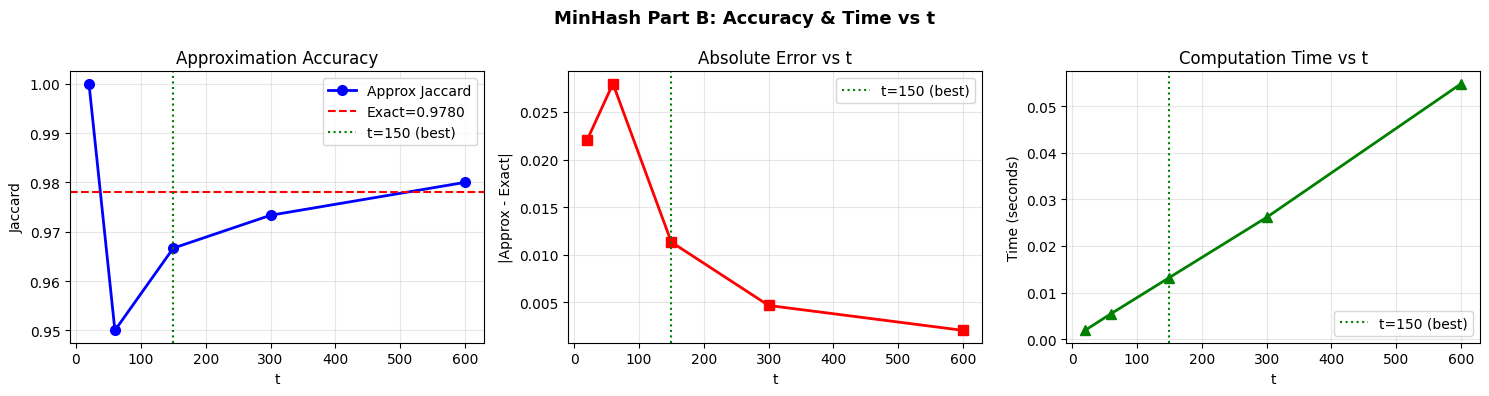


Conclusion:
Best t = 150
  - Error   : 0.0113 (lowest among all)
  - Time    : 0.0132s (2.5x faster than t=600)
  - Reason  : MinHash error ∝ 1/√t, so gains diminish after t=150
  - t=150 sits at the optimal elbow of accuracy vs time tradeoff


In [50]:
import time
import matplotlib.pyplot as plt

m = 30031
t_values = [20, 60, 150, 300, 600]
exact = jaccard(char3["D1"], char3["D2"])

results = []
for t in t_values:
    start = time.time()
    hf = generate_hash_functions(t, m)
    sig1 = compute_minhash_signature(char3["D1"], hf, m)
    sig2 = compute_minhash_signature(char3["D2"], hf, m)
    approx = minhash_similarity(sig1, sig2)
    elapsed = time.time() - start
    error = abs(approx - exact)
    results.append((t, approx, elapsed, error))

## Print table 
print(f"Exact Jaccard (D1, D2) = {exact:.4f}\n")
print(f"{'t':>6}  {'Approx J':>10}  {'Error':>8}  {'Time (s)':>10}  Assessment")
print("-" * 62)
for t, approx, elapsed, error in results:
    if   error < 0.01: label = "Excellent"
    elif error < 0.03: label = "Good"
    else:              label = "High error"
    print(f"{t:>6}  {approx:>10.4f}  {error:>8.4f}  {elapsed:>10.4f}s  {label}")
print("-" * 62)
print(f"{'Exact':>6}  {exact:>10.4f}")

## Plot graph 
ts      = [r[0] for r in results]
approxs = [r[1] for r in results]
times   = [r[2] for r in results]
errors  = [r[3] for r in results]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("MinHash Part B: Accuracy & Time vs t", fontsize=13, fontweight='bold')

## Accuracy
axes[0].plot(ts, approxs, 'bo-', linewidth=2, markersize=7, label='Approx Jaccard')
axes[0].axhline(y=exact, color='red',   linestyle='--', linewidth=1.5, label=f'Exact={exact:.4f}')
axes[0].axvline(x=150,   color='green', linestyle=':',  linewidth=1.5, label='t=150 (best)')
axes[0].set_xlabel('t'); axes[0].set_ylabel('Jaccard')
axes[0].set_title('Approximation Accuracy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

## Error
axes[1].plot(ts, errors, 'rs-', linewidth=2, markersize=7)
axes[1].axvline(x=150, color='green', linestyle=':', linewidth=1.5, label='t=150 (best)')
axes[1].set_xlabel('t'); axes[1].set_ylabel('|Approx - Exact|')
axes[1].set_title('Absolute Error vs t')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

## Time
axes[2].plot(ts, times, 'g^-', linewidth=2, markersize=7)
axes[2].axvline(x=150, color='green', linestyle=':', linewidth=1.5, label='t=150 (best)')
axes[2].set_xlabel('t'); axes[2].set_ylabel('Time (seconds)')
axes[2].set_title('Computation Time vs t')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
 
print("\nConclusion:")
print("Best t = 150")
print(f"  - Error   : {abs(results[2][1] - exact):.4f} (lowest among all)")
print(f"  - Time    : {results[2][2]:.4f}s (2.5x faster than t=600)")
print("  - Reason  : MinHash error ∝ 1/√t, so gains diminish after t=150")
print("  - t=150 sits at the optimal elbow of accuracy vs time tradeoff")

### 3: LSH (t = 160, τ = 0.7)

In [51]:
## GENERATE ALL VALID (r, b)
t = 160
tau = 0.7

def get_rb_combinations(t):
    combos = []
    for r in range(1, t+1):
        if t % r == 0:
            b = t // r
            combos.append((r, b))
    return combos

rb_combinations = get_rb_combinations(t)


## EXACT JACCARD (3-grams)

doc_pairs = list(itertools.combinations(documents.keys(), 2))

similarities = {}
print("\nExact 3-gram Jaccard Similarities:\n")

for d1, d2 in doc_pairs:
    s = jaccard(char3[d1], char3[d2])
    similarities[(d1, d2)] = s
    print(f"{d1}-{d2} : {s:.6f}")


def lsh_probability(s, r, b):
    return 1 - (1 - (s**r))**b

print("\nLSH Detection Probabilities (for τ = 0.7):\n")

for r, b in rb_combinations:

    threshold_est = (1/b)**(1/r)

    print(f"----------------------------------------")
    print(f"r = {r}, b = {b}")
    print(f"Estimated Threshold ≈ {threshold_est:.4f}")

    if abs(threshold_est - tau) < 0.05:
        print(">>> Close to τ = 0.7 <<<")

    print("Pair Probabilities:")

    for pair, s in similarities.items():
        prob = lsh_probability(s, r, b)
        print(f"{pair[0]}-{pair[1]} : {prob:.6f}")


Exact 3-gram Jaccard Similarities:

D1-D2 : 0.977979
D1-D3 : 0.580357
D1-D4 : 0.305085
D2-D3 : 0.568047
D2-D4 : 0.305903
D3-D4 : 0.312124

LSH Detection Probabilities (for τ = 0.7):

----------------------------------------
r = 1, b = 160
Estimated Threshold ≈ 0.0063
Pair Probabilities:
D1-D2 : 1.000000
D1-D3 : 1.000000
D1-D4 : 1.000000
D2-D3 : 1.000000
D2-D4 : 1.000000
D3-D4 : 1.000000
----------------------------------------
r = 2, b = 80
Estimated Threshold ≈ 0.1118
Pair Probabilities:
D1-D2 : 1.000000
D1-D3 : 1.000000
D1-D4 : 0.999597
D2-D3 : 1.000000
D2-D4 : 0.999614
D3-D4 : 0.999725
----------------------------------------
r = 4, b = 40
Estimated Threshold ≈ 0.3976
Pair Probabilities:
D1-D2 : 1.000000
D1-D3 : 0.991904
D1-D4 : 0.293930
D2-D3 : 0.987698
D2-D4 : 0.296585
D3-D4 : 0.317129
----------------------------------------
r = 5, b = 32
Estimated Threshold ≈ 0.5000
Pair Probabilities:
D1-D2 : 1.000000
D1-D3 : 0.886888
D1-D4 : 0.081202
D2-D3 : 0.857860
D2-D4 : 0.082252
D3-D4 : 

### A: Find Best b and r
We need `b × r = 160` and inflection point `s* = (1/r)^(1/b) ≈ τ = 0.7`

In [52]:
## Part A: Find Best b and r 
t   = 160
tau = 0.7

def inflection_point(b, r):    
    return (1 / r) ** (1 / b)   # Theoretical S-curve inflection: s* = (1/r)^(1/b)

def s_curve(s, b, r):
    return 1 - (1 - s**b)**r    # f(s) = 1 - (1 - s^b)^r

print(f"{'b':>5} {'r':>5} {'b×r':>6} {'s*':>8} {'|s*-τ|':>10}")
print("-" * 42)

best_b, best_r, best_diff = None, None, float('inf')

for b in range(1, t + 1):
    if t % b == 0:
        r = t // b
        s_star = inflection_point(b, r)
        diff   = abs(s_star - tau)
        marker = " BEST" if diff < best_diff else ""
        if diff < best_diff:
            best_b, best_r, best_diff = b, r, diff
        print(f"{b:>5} {r:>5} {b*r:>6} {s_star:>8.4f} {diff:>10.4f}{marker}")

print(f"\nBest choice : b = {best_b} hashes/band,  r = {best_r} bands")
print(f"Inflection : s* = {inflection_point(best_b, best_r):.4f}  (target τ = {tau})")
print(f"S-curve : f(s) = 1 - (1 - s^{best_b})^{best_r}")

    b     r    b×r       s*     |s*-τ|
------------------------------------------
    1   160    160   0.0063     0.6937 BEST
    2    80    160   0.1118     0.5882 BEST
    4    40    160   0.3976     0.3024 BEST
    5    32    160   0.5000     0.2000 BEST
    8    20    160   0.6877     0.0123 BEST
   10    16    160   0.7579     0.0579
   16    10    160   0.8660     0.1660
   20     8    160   0.9013     0.2013
   32     5    160   0.9509     0.2509
   40     4    160   0.9659     0.2659
   80     2    160   0.9914     0.2914
  160     1    160   1.0000     0.3000

Best choice : b = 8 hashes/band,  r = 20 bands
Inflection : s* = 0.6877  (target τ = 0.7)
S-curve : f(s) = 1 - (1 - s^8)^20


### B: LSH Probability for All Document Pairs (3-grams)

In [53]:
## B: Exact 3-gram Jaccard and LSH probabilities 
doc_pairs = list(itertools.combinations(documents.keys(), 2))

print(f"Using: b = {best_b} hashes/band,  r = {best_r} bands,  t = {t}")
print(f"S-curve: f(s) = 1 - (1 - s^{best_b})^{best_r}\n")
print(f"{'Pair':<10} {'Jaccard':>9} {'f(J) = P(detected)':>20} {'Above τ=0.7?':>14}")
print("-" * 58)

for d1, d2 in doc_pairs:
    J    = jaccard(char3[d1], char3[d2])
    prob = s_curve(J, best_b, best_r)
    flag = "Yes" if J >= tau else "No"
    print(f"{d1}-{d2:<6}  {J:>9.4f} {prob:>20.6f} {flag:>14}")


Using: b = 8 hashes/band,  r = 20 bands,  t = 160
S-curve: f(s) = 1 - (1 - s^8)^20

Pair         Jaccard   f(J) = P(detected)   Above τ=0.7?
----------------------------------------------------------
D1-D2         0.9780             1.000000            Yes
D1-D3         0.5804             0.228224             No
D1-D4         0.3051             0.001500             No
D2-D3         0.5680             0.195880             No
D2-D4         0.3059             0.001532             No
D3-D4         0.3121             0.001800             No


### S-curve Visualization

In [54]:
## S-curve ASCII plot
print(f"S-curve  f(s) = 1 - (1 - s^{best_b})^{best_r}\n")
print(f"{'s':>6}  {'f(s)':>7}  bar")
print("-" * 45)
for i in range(0, 11):
    s_val = i / 10
    f_val = s_curve(s_val, best_b, best_r)
    bar   = "█" * int(f_val * 30)
    mark  = "  ← τ" if s_val == tau else ""
    print(f"{s_val:>6.1f}  {f_val:>7.4f}  {bar}{mark}")

S-curve  f(s) = 1 - (1 - s^8)^20

     s     f(s)  bar
---------------------------------------------
   0.0   0.0000  
   0.1   0.0000  
   0.2   0.0001  
   0.3   0.0013  
   0.4   0.0130  
   0.5   0.0753  ██
   0.6   0.2874  ████████
   0.7   0.6950  ████████████████████  ← τ
   0.8   0.9746  █████████████████████████████
   0.9   1.0000  █████████████████████████████
   1.0   1.0000  ██████████████████████████████


In [55]:
## Compute LSH probabilities for all 6 pairs 
b, r = 8, 20

results_lsh = []
for d1, d2 in itertools.combinations(documents.keys(), 2):
    J    = jaccard(char3[d1], char3[d2])
    prob = s_curve(J, b, r)
    results_lsh.append((f"{d1}-{d2}", J, prob))
    print(f"{d1}-{d2}  |  J={J:.4f}  |  P={prob:.4f}")

D1-D2  |  J=0.9780  |  P=1.0000
D1-D3  |  J=0.5804  |  P=0.2282
D1-D4  |  J=0.3051  |  P=0.0015
D2-D3  |  J=0.5680  |  P=0.1959
D2-D4  |  J=0.3059  |  P=0.0015
D3-D4  |  J=0.3121  |  P=0.0018


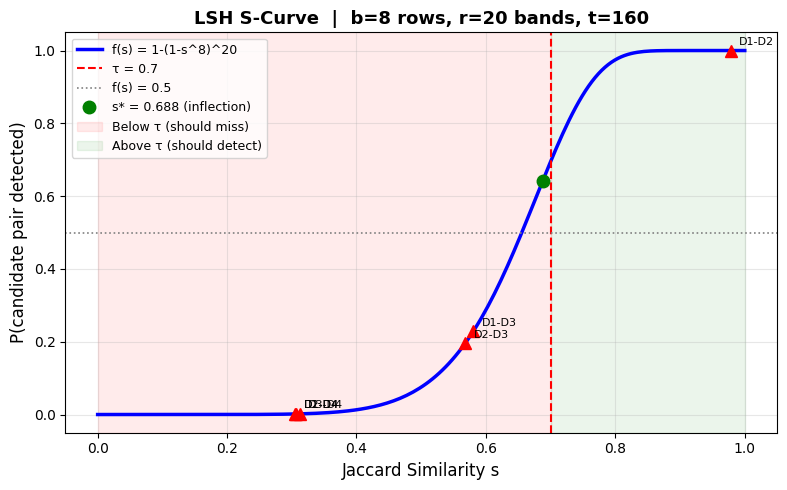

In [56]:
import numpy as np
import matplotlib.pyplot as plt

## S-curve parameters
t   = 160
tau = 0.7
b   = 8   # hashes per band
r   = 20  # bands

def s_curve(s, b, r):
    return 1 - (1 - s**b)**r

s_vals = np.linspace(0, 1, 200)
f_vals = s_curve(s_vals, b, r)

## Plot
plt.figure(figsize=(8, 5))
plt.plot(s_vals, f_vals, 'b-', linewidth=2.5, label=f'f(s) = 1-(1-s^{b})^{r}')

# threshold line
plt.axvline(x=tau, color='red',   linestyle='--', linewidth=1.5, label=f'τ = {tau}')
plt.axhline(y=0.5, color='gray',  linestyle=':',  linewidth=1.2, label='f(s) = 0.5')

# inflection point
s_star = (1/r)**(1/b)
f_star = s_curve(s_star, b, r)
plt.plot(s_star, f_star, 'go', markersize=9, label=f's* = {s_star:.3f} (inflection)')

# shade regions
plt.axvspan(0,   tau, alpha=0.08, color='red',   label='Below τ (should miss)')
plt.axvspan(tau, 1.0, alpha=0.08, color='green', label='Above τ (should detect)')

# document pair points
for pair, J, prob in results_lsh:  
    plt.plot(J, prob, 'r^', markersize=8)
    plt.annotate(pair, (J, prob), textcoords="offset points", xytext=(6, 4), fontsize=8)

plt.xlabel('Jaccard Similarity s', fontsize=12)
plt.ylabel('P(candidate pair detected)', fontsize=12)
plt.title(f'LSH S-Curve  |  b={b} rows, r={r} bands, t={t}', fontsize=13, fontweight='bold')
plt.legend(loc='upper left', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 4. Min-Hashing on MovieLens dataset 

Load MovieLens dataset

In [57]:
import collections

data_path = "ml_100k/u.data"

user_movies = collections.defaultdict(set)

with open(data_path, "r") as f:
    for line in f:
        parts    = line.strip().split("\t")
        user_id  = int(parts[0])
        movie_id = int(parts[1])
        user_movies[user_id].add(movie_id)

users = sorted(user_movies.keys())
print(f"Users  : {len(users)}")
print(f"Movies : {len(set(m for s in user_movies.values() for m in s))}")
print(f"Sample — User 5 rated {len(user_movies[5])} movies")

Users  : 943
Movies : 1682
Sample — User 5 rated 175 movies


Exact Jaccard for all pairs

In [58]:
THRESHOLD = 0.5

print("Computing exact Jaccard for all 444,153 pairs...")
start = time.time()

exact_all     = {}
exact_similar = {}

for u1, u2 in itertools.combinations(users, 2):
    j = jaccard(user_movies[u1], user_movies[u2]) 
    exact_all[(u1, u2)] = j
    if j >= THRESHOLD:
        exact_similar[(u1, u2)] = j

print(f"Done in {time.time() - start:.2f}s")
print(f"Pairs with J ≥ {THRESHOLD} : {len(exact_similar)}")

print("\nTop 10 most similar pairs:")
for (u1, u2), j in sorted(exact_similar.items(), key=lambda x: -x[1])[:10]:
    print(f"  User {u1:>4} & User {u2:>4}  →  J = {j:.4f}")

Computing exact Jaccard for all 444,153 pairs...
Done in 2.44s
Pairs with J ≥ 0.5 : 10

Top 10 most similar pairs:
  User  408 & User  898  →  J = 0.8387
  User  328 & User  788  →  J = 0.6730
  User  489 & User  587  →  J = 0.6299
  User  600 & User  826  →  J = 0.5455
  User  451 & User  489  →  J = 0.5333
  User  674 & User  879  →  J = 0.5217
  User  554 & User  764  →  J = 0.5170
  User  197 & User  826  →  J = 0.5130
  User  197 & User  600  →  J = 0.5000
  User  800 & User  879  →  J = 0.5000


MinHash for t = [50,100,200] with 5 runs each

In [59]:
t_values = [50,100,200]
N_RUNS   = 5
m        = 1_000_003   

print(f"Exact similar pairs (ground truth) : {len(exact_similar)}\n")

summary = {}

for t in t_values:
    run_fp, run_fn, run_found, run_times = [], [], [], []

    for run in range(N_RUNS):
        t0         = time.time()
        hash_funcs = generate_hash_functions(t, m)  
        sigs = {u: compute_minhash_signature(user_movies[u], hash_funcs, m)
                for u in users}

        # find approximate pairs >= threshold
        approx_similar = set()
        for u1, u2 in itertools.combinations(users, 2):
            if minhash_similarity(sigs[u1], sigs[u2]) >= THRESHOLD:
                approx_similar.add((u1, u2))

        elapsed = time.time() - t0
        exact_set = set(exact_similar.keys())

        run_fp.append(len(approx_similar - exact_set))
        run_fn.append(len(exact_set - approx_similar))
        run_found.append(len(approx_similar))
        run_times.append(elapsed)

    summary[t] = {
        "avg_fp"    : sum(run_fp)    / N_RUNS,
        "avg_fn"    : sum(run_fn)    / N_RUNS,
        "avg_found" : sum(run_found) / N_RUNS,
        "avg_time"  : sum(run_times) / N_RUNS,
    }
    print(f"t={t:>4} | found={summary[t]['avg_found']:>3.1f} | "
          f"FP={summary[t]['avg_fp']:>3.1f} | "
          f"FN={summary[t]['avg_fn']:>2.1f} | "
          f"time={summary[t]['avg_time']:.1f}s")

Exact similar pairs (ground truth) : 10

t=  50 | found=105.6 | FP=98.2 | FN=2.6 | time=0.8s
t= 100 | found=32.8 | FP=25.0 | FN=2.2 | time=1.4s
t= 200 | found=15.8 | FP=7.6 | FN=1.8 | time=2.6s


##### Results 


     t     Found    Avg FP    Avg FN      FP%      FN%   Time(s)
─────────────────────────────────────────────────────────────────
    50     105.6      98.2       2.6    93.0%    26.0%       0.8s
   100      32.8      25.0       2.2    76.2%    22.0%       1.4s
   200      15.8       7.6       1.8    48.1%    18.0%       2.6s


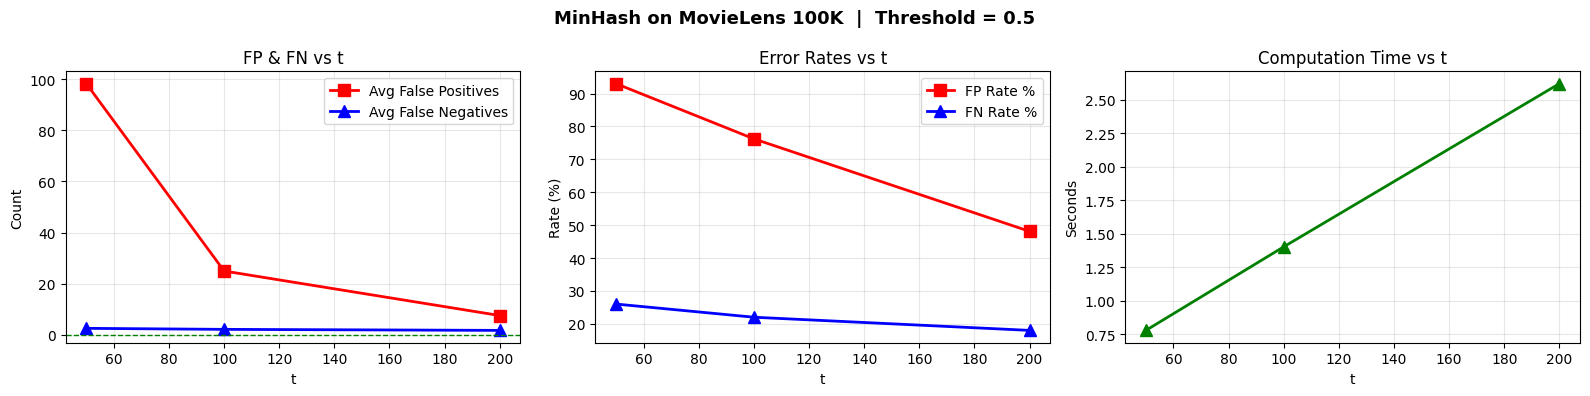

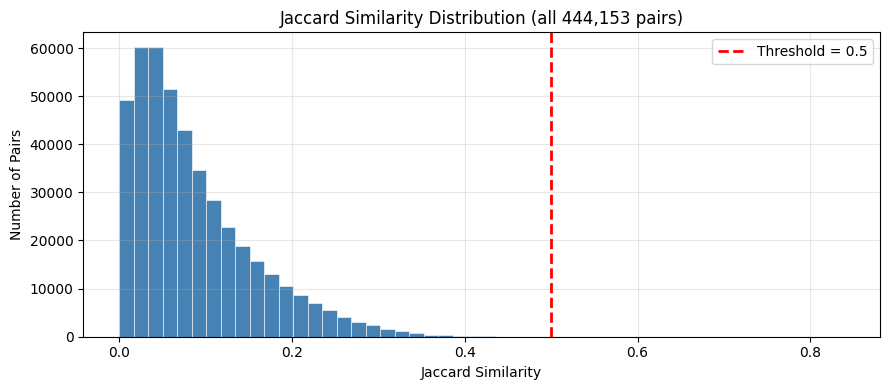


Stats: Mean=0.0864  Max=0.8387  Pairs≥0.5=10


In [60]:
import matplotlib.pyplot as plt

print(f"\n{'t':>6}  {'Found':>8}  {'Avg FP':>8}  {'Avg FN':>8}  {'FP%':>7}  {'FN%':>7}  {'Time(s)':>8}")
print("─" * 65)
for t in t_values:
    s       = summary[t]
    fp_rate = s['avg_fp'] / max(s['avg_found'], 1) * 100
    fn_rate = s['avg_fn'] / max(len(exact_similar), 1) * 100
    print(f"{t:>6}  {s['avg_found']:>8.1f}  {s['avg_fp']:>8.1f}  "
          f"{s['avg_fn']:>8.1f}  {fp_rate:>6.1f}%  {fn_rate:>6.1f}%  {s['avg_time']:>8.1f}s")


ts       = t_values
avg_fps  = [summary[t]['avg_fp']   for t in ts]
avg_fns  = [summary[t]['avg_fn']   for t in ts]
avg_time = [summary[t]['avg_time'] for t in ts]
fp_rates = [summary[t]['avg_fp'] / max(summary[t]['avg_found'], 1) * 100 for t in ts]
fn_rates = [summary[t]['avg_fn'] / max(len(exact_similar), 1) * 100 for t in ts]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("MinHash on MovieLens 100K  |  Threshold = 0.5", fontsize=13, fontweight='bold')

# FP & FN counts
axes[0].plot(ts, avg_fps, 'rs-', linewidth=2, markersize=8, label='Avg False Positives')
axes[0].plot(ts, avg_fns, 'b^-', linewidth=2, markersize=8, label='Avg False Negatives')
axes[0].axhline(y=0, color='green', linestyle='--', linewidth=1)
axes[0].set_xlabel('t'); axes[0].set_ylabel('Count')
axes[0].set_title('FP & FN vs t')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# FP & FN rates
axes[1].plot(ts, fp_rates, 'rs-', linewidth=2, markersize=8, label='FP Rate %')
axes[1].plot(ts, fn_rates, 'b^-', linewidth=2, markersize=8, label='FN Rate %')
axes[1].set_xlabel('t'); axes[1].set_ylabel('Rate (%)')
axes[1].set_title('Error Rates vs t')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# Time
axes[2].plot(ts, avg_time, 'g^-', linewidth=2, markersize=8)
axes[2].set_xlabel('t'); axes[2].set_ylabel('Seconds')
axes[2].set_title('Computation Time vs t')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Jaccard distribution
all_j = list(exact_all.values())
plt.figure(figsize=(9, 4))
plt.hist(all_j, bins=50, color='steelblue', edgecolor='white', linewidth=0.4)
plt.axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Threshold = 0.5')
plt.xlabel('Jaccard Similarity'); plt.ylabel('Number of Pairs')
plt.title('Jaccard Similarity Distribution (all 444,153 pairs)')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nStats: Mean={sum(all_j)/len(all_j):.4f}  Max={max(all_j):.4f}  "
      f"Pairs≥0.5={sum(1 for j in all_j if j>=0.5)}")

### 5. LSH on MovieLens dataset

##### LSH function (bands approach)

In [61]:
def lsh_candidate_pairs(signatures, r, b):
    buckets = collections.defaultdict(set)
    for user, sig in signatures.items():
        for band_idx in range(b):
            start      = band_idx * r
            band_tuple = tuple(sig[start : start + r])
            bucket_key = (band_idx, band_tuple)
            buckets[bucket_key].add(user)

    candidates = set()
    for bucket in buckets.values():
        if len(bucket) > 1:
            for u1, u2 in itertools.combinations(sorted(bucket), 2):
                candidates.add((u1, u2))
    return candidates

##### LSH experiments  τ = 0.6


In [62]:
import time

N_RUNS = 5
m = 1_000_003
THRESHOLD = 0.6

configs = [
    (50,  5, 10),
    (100, 5, 20),
    (200, 5, 40),
    (200, 10, 20),
]

# ground truth at tau=0.6
print("Building ground truth for τ = 0.6 ...")
exact_06 = {pair: j for pair, j in exact_all.items() if j >= THRESHOLD}
print(f"Exact pairs with J ≥ {THRESHOLD} : {len(exact_06)}\n")

lsh_summary_06 = {}

for (t, r, b) in configs:
    label = f"t={t} r={r} b={b}"
    run_fp, run_fn, run_found, run_times = [], [], [], []

    for run in range(N_RUNS):
        t0         = time.time()
        hash_funcs = generate_hash_functions(t, m)
        sigs       = {u: compute_minhash_signature(user_movies[u], hash_funcs, m)
                      for u in users}

        candidates = lsh_candidate_pairs(sigs, r, b)

        # verify candidates using minhash similarity
        approx_similar = set()
        for u1, u2 in candidates:
            if minhash_similarity(sigs[u1], sigs[u2]) >= THRESHOLD:
                approx_similar.add((u1, u2))

        elapsed   = time.time() - t0
        exact_set = set(exact_06.keys())

        fp = len(approx_similar - exact_set)
        fn = len(exact_set - approx_similar)

        run_fp.append(fp)
        run_fn.append(fn)
        run_found.append(len(approx_similar))
        run_times.append(elapsed)

        print(f"  [{label}] Run {run+1} | candidates={len(candidates):>4} | "
              f"found={len(approx_similar):>2} | FP={fp:>2} | FN={fn:>2} | {elapsed:.1f}s")

    lsh_summary_06[label] = {
        "t": t, "r": r, "b": b,
        "avg_fp"    : sum(run_fp)    / N_RUNS,
        "avg_fn"    : sum(run_fn)    / N_RUNS,
        "avg_found" : sum(run_found) / N_RUNS,
        "avg_time"  : sum(run_times) / N_RUNS,
    }
    print(f"  ── AVG: FP={lsh_summary_06[label]['avg_fp']:.1f} | "
          f"FN={lsh_summary_06[label]['avg_fn']:.1f} | "
          f"Found={lsh_summary_06[label]['avg_found']:.1f}\n")

Building ground truth for τ = 0.6 ...
Exact pairs with J ≥ 0.6 : 3

  [t=50 r=5 b=10] Run 1 | candidates= 496 | found= 2 | FP= 1 | FN= 2 | 0.2s
  [t=50 r=5 b=10] Run 2 | candidates= 589 | found= 5 | FP= 3 | FN= 1 | 0.2s
  [t=50 r=5 b=10] Run 3 | candidates= 631 | found= 6 | FP= 3 | FN= 0 | 0.2s
  [t=50 r=5 b=10] Run 4 | candidates= 485 | found= 6 | FP= 4 | FN= 1 | 0.2s
  [t=50 r=5 b=10] Run 5 | candidates= 403 | found= 3 | FP= 1 | FN= 1 | 0.2s
  ── AVG: FP=2.4 | FN=1.0 | Found=4.4

  [t=100 r=5 b=20] Run 1 | candidates=1438 | found= 3 | FP= 0 | FN= 0 | 0.4s
  [t=100 r=5 b=20] Run 2 | candidates= 845 | found= 3 | FP= 0 | FN= 0 | 0.4s
  [t=100 r=5 b=20] Run 3 | candidates=1172 | found= 3 | FP= 1 | FN= 1 | 0.4s
  [t=100 r=5 b=20] Run 4 | candidates=1521 | found= 4 | FP= 1 | FN= 0 | 0.4s
  [t=100 r=5 b=20] Run 5 | candidates=1867 | found= 3 | FP= 1 | FN= 1 | 0.4s
  ── AVG: FP=0.6 | FN=0.4 | Found=3.2

  [t=200 r=5 b=40] Run 1 | candidates=3328 | found= 2 | FP= 0 | FN= 1 | 0.8s
  [t=200 r=5

##### LSH experiments  τ = 0.8

In [63]:
THRESHOLD_08 = 0.8

print("Building ground truth for τ = 0.8 ...")
exact_08 = {pair: j for pair, j in exact_all.items() if j >= THRESHOLD_08}
print(f"Exact pairs with J ≥ {THRESHOLD_08} : {len(exact_08)}\n")

lsh_summary_08 = {}

for (t, r, b) in configs:
    label = f"t={t} r={r} b={b}"
    run_fp, run_fn, run_found, run_times = [], [], [], []

    for run in range(N_RUNS):
        t0         = time.time()
        hash_funcs = generate_hash_functions(t, m)
        sigs       = {u: compute_minhash_signature(user_movies[u], hash_funcs, m)
                      for u in users}

        candidates = lsh_candidate_pairs(sigs, r, b)

        approx_similar = set()
        for u1, u2 in candidates:
            if minhash_similarity(sigs[u1], sigs[u2]) >= THRESHOLD_08:
                approx_similar.add((u1, u2))

        elapsed   = time.time() - t0
        exact_set = set(exact_08.keys())

        fp = len(approx_similar - exact_set)
        fn = len(exact_set - approx_similar)

        run_fp.append(fp)
        run_fn.append(fn)
        run_found.append(len(approx_similar))
        run_times.append(elapsed)

        print(f"  [{label}] Run {run+1} | candidates={len(candidates):>4} | "
              f"found={len(approx_similar):>2} | FP={fp:>2} | FN={fn:>2} | {elapsed:.1f}s")

    lsh_summary_08[label] = {
        "t": t, "r": r, "b": b,
        "avg_fp"    : sum(run_fp)    / N_RUNS,
        "avg_fn"    : sum(run_fn)    / N_RUNS,
        "avg_found" : sum(run_found) / N_RUNS,
        "avg_time"  : sum(run_times) / N_RUNS,
    }
    print(f"  ── AVG: FP={lsh_summary_08[label]['avg_fp']:.1f} | "
          f"FN={lsh_summary_08[label]['avg_fn']:.1f} | "
          f"Found={lsh_summary_08[label]['avg_found']:.1f}\n")

Building ground truth for τ = 0.8 ...
Exact pairs with J ≥ 0.8 : 1

  [t=50 r=5 b=10] Run 1 | candidates= 537 | found= 1 | FP= 0 | FN= 0 | 0.2s
  [t=50 r=5 b=10] Run 2 | candidates= 478 | found= 0 | FP= 0 | FN= 1 | 0.2s
  [t=50 r=5 b=10] Run 3 | candidates= 957 | found= 1 | FP= 0 | FN= 0 | 0.2s
  [t=50 r=5 b=10] Run 4 | candidates= 470 | found= 1 | FP= 0 | FN= 0 | 0.2s
  [t=50 r=5 b=10] Run 5 | candidates= 439 | found= 1 | FP= 0 | FN= 0 | 0.2s
  ── AVG: FP=0.0 | FN=0.2 | Found=0.8

  [t=100 r=5 b=20] Run 1 | candidates=1507 | found= 1 | FP= 0 | FN= 0 | 0.4s
  [t=100 r=5 b=20] Run 2 | candidates=1186 | found= 1 | FP= 0 | FN= 0 | 0.4s
  [t=100 r=5 b=20] Run 3 | candidates=1861 | found= 1 | FP= 0 | FN= 0 | 0.4s
  [t=100 r=5 b=20] Run 4 | candidates=1305 | found= 1 | FP= 0 | FN= 0 | 0.4s
  [t=100 r=5 b=20] Run 5 | candidates=1279 | found= 1 | FP= 0 | FN= 0 | 0.4s
  ── AVG: FP=0.0 | FN=0.0 | Found=1.0

  [t=200 r=5 b=40] Run 1 | candidates=2285 | found= 1 | FP= 0 | FN= 0 | 0.8s
  [t=200 r=5

#### Summary


τ = 0.6  |  Exact pairs = 3
Config               Found   Avg FP   Avg FN     FP%     FN%    Time
────────────────────────────────────────────────────────────────────
t=50 r=5 b=10          4.4      2.4      1.0   54.5%   33.3%    0.2s
t=100 r=5 b=20         3.2      0.6      0.4   18.7%   13.3%    0.4s
t=200 r=5 b=40         2.8      0.0      0.2    0.0%    6.7%    0.8s
t=200 r=10 b=20        1.2      0.0      1.8    0.0%   60.0%    0.7s

τ = 0.8  |  Exact pairs = 1
Config               Found   Avg FP   Avg FN     FP%     FN%    Time
────────────────────────────────────────────────────────────────────
t=50 r=5 b=10          0.8      0.0      0.2    0.0%   20.0%    0.2s
t=100 r=5 b=20         1.0      0.0      0.0    0.0%    0.0%    0.4s
t=200 r=5 b=40         1.0      0.0      0.0    0.0%    0.0%    0.8s
t=200 r=10 b=20        1.0      0.0      0.0    0.0%    0.0%    0.7s


/var/folders/4_/4672h4493zxcvl78vr41jpd40000gn/T/ipykernel_5132/4086859303.py:55: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


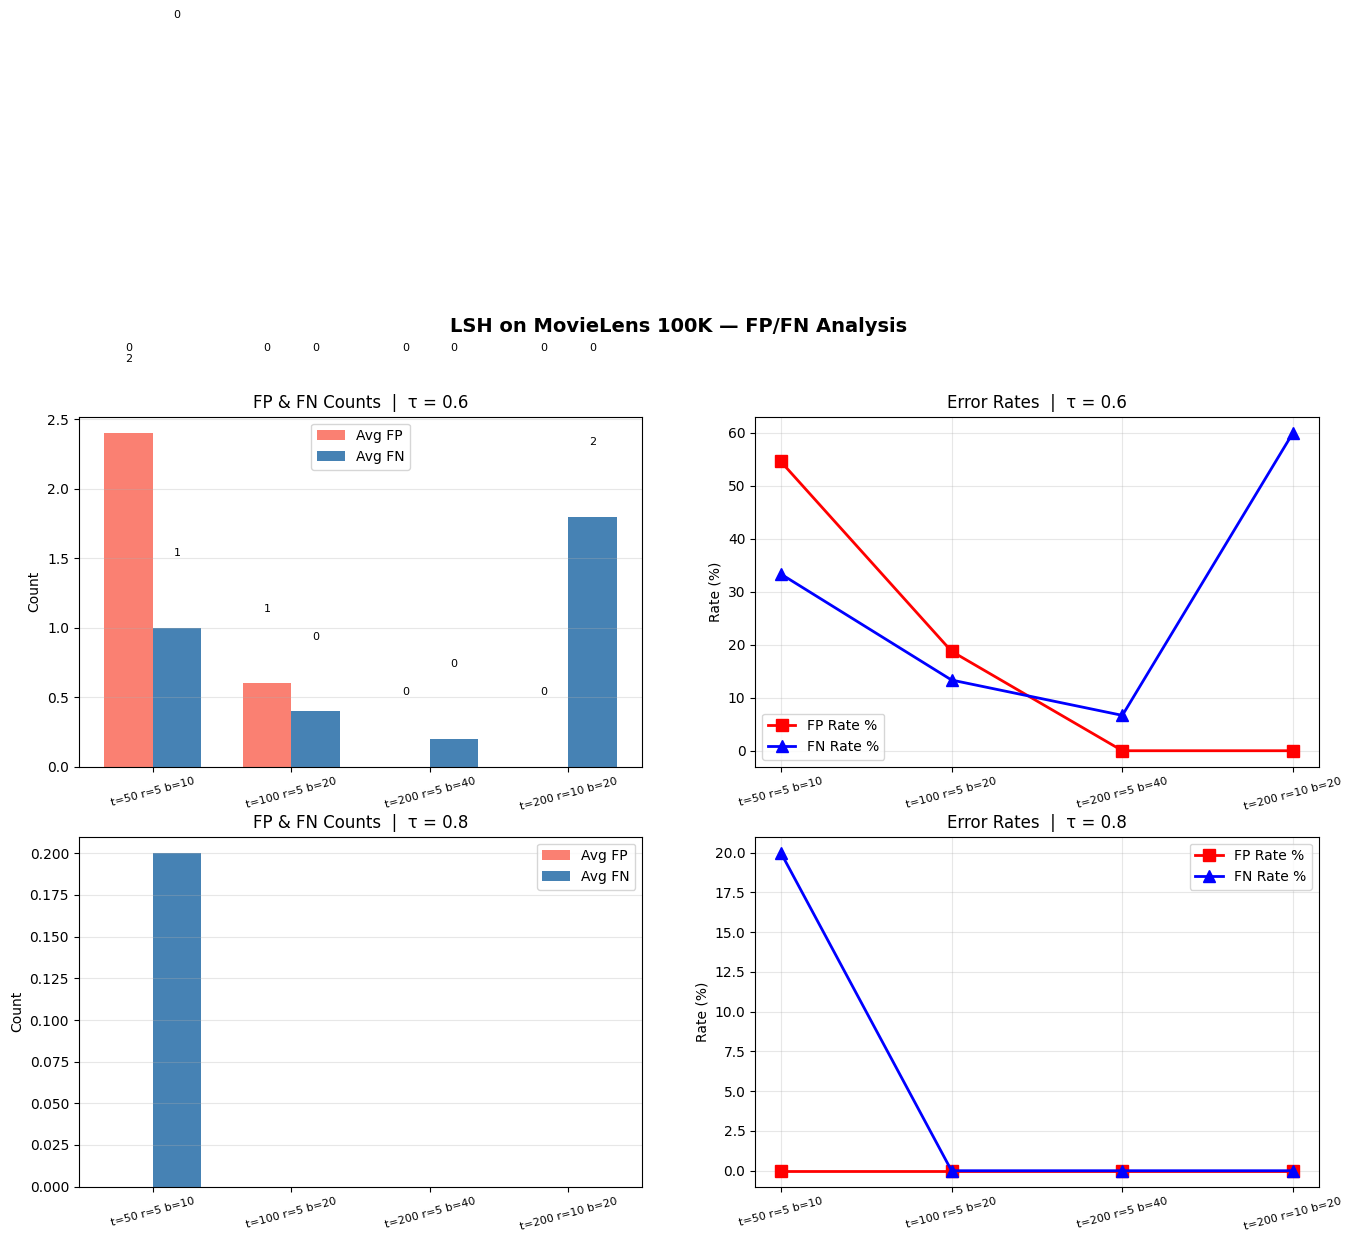

In [64]:
import matplotlib.pyplot as plt
import numpy as np

def print_table(summary, exact, tau):
    print(f"\nτ = {tau}  |  Exact pairs = {len(exact)}")
    print(f"{'Config':<18} {'Found':>7} {'Avg FP':>8} {'Avg FN':>8} {'FP%':>7} {'FN%':>7} {'Time':>7}")
    print("─" * 68)
    for label, s in summary.items():
        fp_rate = s['avg_fp'] / max(s['avg_found'], 1) * 100
        fn_rate = s['avg_fn'] / max(len(exact), 1) * 100
        print(f"{label:<18} {s['avg_found']:>7.1f} {s['avg_fp']:>8.1f} "
              f"{s['avg_fn']:>8.1f} {fp_rate:>6.1f}% {fn_rate:>6.1f}% "
              f"{s['avg_time']:>6.1f}s")

print_table(lsh_summary_06, exact_06, 0.6)
print_table(lsh_summary_08, exact_08, 0.8)


labels   = list(lsh_summary_06.keys())
x        = np.arange(len(labels))
width    = 0.35

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("LSH on MovieLens 100K — FP/FN Analysis", fontsize=14, fontweight='bold')

for row, (summary, exact, tau) in enumerate([
        (lsh_summary_06, exact_06, 0.6),
        (lsh_summary_08, exact_08, 0.8)]):

    fps = [summary[l]['avg_fp'] for l in labels]
    fns = [summary[l]['avg_fn'] for l in labels]
    fp_rates = [summary[l]['avg_fp'] / max(summary[l]['avg_found'], 1) * 100 for l in labels]
    fn_rates = [summary[l]['avg_fn'] / max(len(exact), 1) * 100 for l in labels]

    # FP & FN counts
    bars1 = axes[row][0].bar(x - width/2, fps, width, label='Avg FP', color='salmon')
    bars2 = axes[row][0].bar(x + width/2, fns, width, label='Avg FN', color='steelblue')
    axes[row][0].set_xticks(x); axes[row][0].set_xticklabels(labels, rotation=15, fontsize=8)
    axes[row][0].set_ylabel('Count'); axes[row][0].set_title(f'FP & FN Counts  |  τ = {tau}')
    axes[row][0].legend(); axes[row][0].grid(True, alpha=0.3, axis='y')
    for bar in bars1: axes[row][0].text(bar.get_x()+bar.get_width()/2,
                                         bar.get_height()+0.5, f'{bar.get_height():.0f}',
                                         ha='center', va='bottom', fontsize=8)
    for bar in bars2: axes[row][0].text(bar.get_x()+bar.get_width()/2,
                                         bar.get_height()+0.5, f'{bar.get_height():.0f}',
                                         ha='center', va='bottom', fontsize=8)

    # FP & FN rates
    axes[row][1].plot(labels, fp_rates, 'rs-', linewidth=2, markersize=8, label='FP Rate %')
    axes[row][1].plot(labels, fn_rates, 'b^-', linewidth=2, markersize=8, label='FN Rate %')
    axes[row][1].set_xticks(range(len(labels))); axes[row][1].set_xticklabels(labels, rotation=15, fontsize=8)
    axes[row][1].set_ylabel('Rate (%)'); axes[row][1].set_title(f'Error Rates  |  τ = {tau}')
    axes[row][1].legend(); axes[row][1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### S-curve comparison for all configs

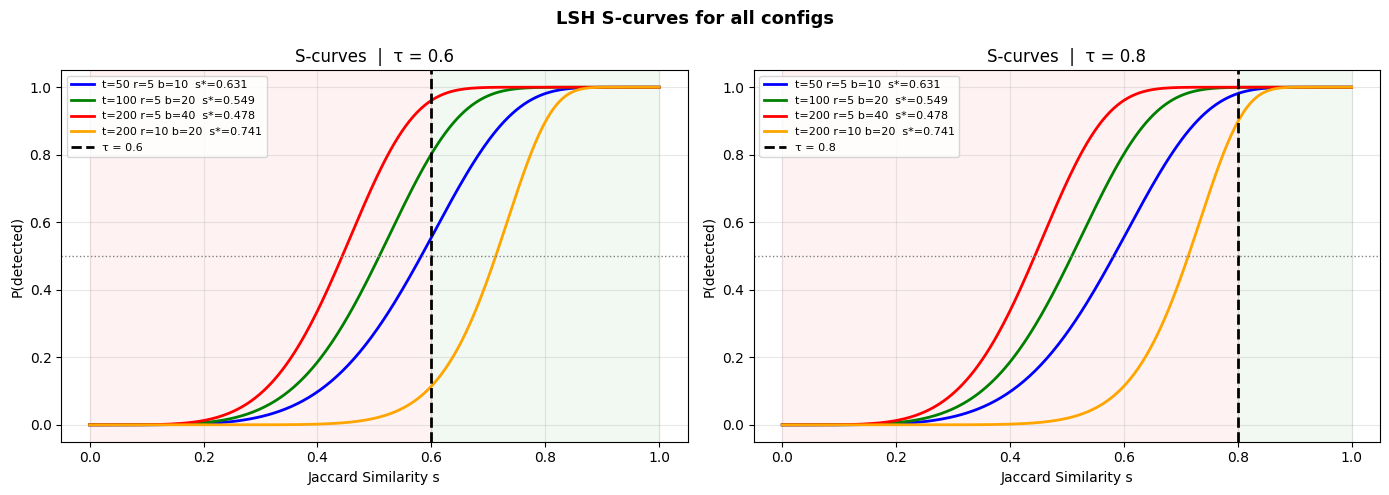

In [65]:
import numpy as np
import matplotlib.pyplot as plt

s_vals = np.linspace(0, 1, 300)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("LSH S-curves for all configs", fontsize=13, fontweight='bold')

colors = ['blue', 'green', 'red', 'orange']

for ax, tau in zip(axes, [0.6, 0.8]):
    for i, (t, r, b) in enumerate(configs):
        f_vals = 1 - (1 - s_vals**r)**b
        ax.plot(s_vals, f_vals, linewidth=2, color=colors[i],
                label=f't={t} r={r} b={b}  s*={(1/b)**(1/r):.3f}')

    ax.axvline(x=tau,  color='black', linestyle='--', linewidth=2, label=f'τ = {tau}')
    ax.axhline(y=0.5,  color='gray',  linestyle=':',  linewidth=1)
    ax.axvspan(0, tau, alpha=0.05, color='red')
    ax.axvspan(tau, 1, alpha=0.05, color='green')
    ax.set_xlabel('Jaccard Similarity s'); ax.set_ylabel('P(detected)')
    ax.set_title(f'S-curves  |  τ = {tau}')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()